The following additional libraries are needed to run this
notebook. Note that running on Colab is experimental, please report a Github
issue if you have any problem.

# Converting Raw Text into Sequence Data


Throughout this book,
we will often work with text data
represented as sequences
of words, characters, or word pieces.
To get going, we will need some basic
tools for converting raw text
into sequences of the appropriate form.
Typical preprocessing pipelines
execute the following steps:

1. Load text as strings into memory.
1. Split the strings into tokens (e.g., words or characters).
1. Build a vocabulary dictionary to associate each vocabulary element with a numerical index.
1. Convert the text into sequences of numerical indices.


In [1]:
import collections
import random
import re
import torch
from torch import nn

## Reading the Dataset

Here, we will work with H. G. Wells'
[The Time Machine](http://www.gutenberg.org/ebooks/35),
a book containing just over 30,000 words.
While real applications will typically
involve significantly larger datasets,
this is sufficient to demonstrate
the preprocessing pipeline.
The following `_download` method
(**reads the raw text into a string**).


In [17]:
from pathlib import Path
import hashlib
import urllib.request


class TimeMachine:
    """The Time Machine dataset."""
    def __init__(self, root="./data"):
        self.root = Path(root)

    def _download(self):
        url = "https://d2l-data.s3-accelerate.amazonaws.com/timemachine.txt"

        self.root.mkdir(parents=True, exist_ok=True)
        fname = self.root / "timemachine.txt"

        # Download only if missing
        if not fname.exists():
            urllib.request.urlretrieve(url, fname)

        with open(fname, "r", encoding="utf-8") as f:
            return f.read()

data = TimeMachine()
raw_text = data._download()
raw_text[:60]

'The Time Machine, by H. G. Wells [1898]\n\n\n\n\nI\n\n\nThe Time Tra'

For simplicity, we ignore punctuation and capitalization when preprocessing the raw text.


In [20]:
import re

def _preprocess(self, text):
    # replaces every chunk of non-letters with a single space ' ',
    # A-Za-z = any English letter (uppercase or lowercase)
    # + = one or more in a row
    # return re.sub('[^A-Za-z]+', ' ', text).lower()
    proc_text=re.sub('[^A-Za-z]+', ' ', text)
    return proc_text.lower()

TimeMachine._preprocess=_preprocess
text = data._preprocess(raw_text)
raw_text[:60], text[:60]

('The Time Machine, by H. G. Wells [1898]\n\n\n\n\nI\n\n\nThe Time Tra',
 'the time machine by h g wells i the time traveller for so it')

## Tokenization

*Tokens* are the atomic (indivisible) units of text.
Each time step corresponds to 1 token,
but what precisely constitutes a token is a design choice.
For example, we could represent the sentence
"Baby needs a new pair of shoes"
as a sequence of 7 words,
where the set of all words comprise
a large vocabulary (typically tens
or hundreds of thousands of words).
Or we would represent the same sentence
as a much longer sequence of 30 characters,
using a much smaller vocabulary
(there are only 256 distinct ASCII characters).
Below, we tokenize our preprocessed text
into a sequence of characters.


In [21]:

def _tokenize(self, text):
    return list(text)

TimeMachine._tokenize=_tokenize
tokens = data._tokenize(text)
','.join(tokens[:30])

't,h,e, ,t,i,m,e, ,m,a,c,h,i,n,e, ,b,y, ,h, ,g, ,w,e,l,l,s, '

## Vocabulary

These tokens are still strings.
However, the inputs to our models
must ultimately consist
of numerical inputs.
[**Next, we introduce a class
for constructing *vocabularies*,
i.e., objects that associate
each distinct token value
with a unique index.**]
First, we determine the set of unique tokens in our training *corpus*.
We then assign a numerical index to each unique token.
Rare vocabulary elements are often dropped for convenience.
Whenever we encounter a token at training or test time
that had not been previously seen or was dropped from the vocabulary,
we represent it by a special "&lt;unk&gt;" token,
signifying that this is an *unknown* value.


In [22]:
from collections.abc import Iterable


class Vocab:
    """Vocabulary for text."""
    def __init__(self, tokens=[], min_freq=0, reserved_tokens=[]):
        # Flatten a 2D list if needed

        if tokens and isinstance(tokens[0], list):
            tokens = [token for line in tokens for token in line]
        # Count token frequencies
        freq = {}
        for t in tokens:
          freq[t] = freq.get(t,0)+1


        # Sort by frequency (high -> low)
        self.token_freqs = sorted(freq.items(), key=lambda x: x[1], reverse=True)

        # The list of unique tokens
        self.idx_to_token=[]
        for token, freq in self.token_freqs:
          if freq >=min_freq:
            self.idx_to_token.append(token)
        self.idx_to_token.append(['<unk>'])

        self.idx_to_token = list(sorted(set(['<unk>'] + reserved_tokens + [
            token for token, freq in self.token_freqs if freq >= min_freq])))
        self.token_to_idx={}
        for idx, token in enumerate(self.idx_to_token):
          self.token_to_idx[token]=idx
        self.token_to_idx = {token: idx
                             for idx, token in enumerate(self.idx_to_token)}

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):
      # Case 1: `tokens` is a single token (e.g., a string like "the")
      # Return its index if it exists; otherwise return the unknown-token index `self.unk`.
      if not isinstance(tokens, (list, tuple)):
          ### OOV out-of-vocabulary
          return self.token_to_idx.get(tokens, self.unk)

      # Case 2: `tokens` is a list/tuple of tokens (e.g., ["the", "time", "machine"])
      # Convert each token to its index, preserving order.
      # Uses self.__getitem__ recursively so the same "single token" logic applies.
      return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
      # If `indices` looks like a sequence (list/tuple/numpy array/torch tensor),
      # convert each element to an int index and map it to its token.
      # (Exclude strings/bytes so we don't iterate over characters.)
      if hasattr(indices, "__len__") and not isinstance(indices, (str, bytes)):
        temp=[]
        for i in indices:
          one_token=self.idx_to_token[int(i)]
          temp.append(one_token)
        return temp

        # return [self.idx_to_token[int(i)] for i in indices]

      # Otherwise, treat `indices` as a single scalar index and return one token.
      return self.idx_to_token[int(indices)]

    @property
    def unk(self):  # Index for the unknown token
        return self.token_to_idx['<unk>']

We now [**construct a vocabulary**] for our dataset,
converting the sequence of strings
into a list of numerical indices.
Note that we have not lost any information
and can easily convert our dataset
back to its original (string) representation.


In [24]:
vocab = Vocab(tokens)
print("tokens:",tokens[:10])
indices = vocab[tokens[:10]]
print('indices:', indices)
print('words:', vocab.to_tokens(indices))

tokens: ['t', 'h', 'e', ' ', 't', 'i', 'm', 'e', ' ', 'm']
indices: [21, 9, 6, 0, 21, 10, 14, 6, 0, 14]
words: ['t', 'h', 'e', ' ', 't', 'i', 'm', 'e', ' ', 'm']


## Putting It All Together

Using the above classes and methods,
we [**package everything into the following
`build` method of the `TimeMachine` class**],
which returns `corpus`, a list of token indices, and `vocab`,
the vocabulary of *The Time Machine* corpus.
The modifications we did here are:
(i) we tokenize text into characters, not words,
to simplify the training in later sections;
(ii) `corpus` is a single list, not a list of token lists,
since each text line in *The Time Machine* dataset
is not necessarily a sentence or paragraph.


In [29]:
def build(self, raw_text, vocab=None):
    # 1) Clean/normalize the raw text (e.g., lowercase, remove punctuation)
    #    then split it into a list of tokens (words/characters depending on tokenizer).

    ## tokens = self._tokenize(self._preprocess(raw_text))
    tokens = self._tokenize(self._preprocess(raw_text))

    # 2) If no vocabulary is provided, build a new one from these tokens.
    #    The vocab maps token -> index (and often keeps idx -> token too).

    # if vocab is None: vocab = Vocab(tokens)
    vocab=Vocab(tokens)


    # 3) Convert the token sequence into a numeric corpus (list of token indices).

    # corpus = [vocab[token] for token in tokens]
    corpus = [vocab[token] for token in tokens]
    ## TODO

    # 4) Return both the numeric corpus and the vocabulary used to build it.
    return corpus, vocab

TimeMachine.build=build
corpus, vocab = data.build(raw_text)
len(corpus), len(vocab)
print("idx_to_token", vocab.idx_to_token)
print("token_to_idx", vocab.token_to_idx)
print(corpus[:20])

idx_to_token [' ', '<unk>', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
token_to_idx {' ': 0, '<unk>': 1, 'a': 2, 'b': 3, 'c': 4, 'd': 5, 'e': 6, 'f': 7, 'g': 8, 'h': 9, 'i': 10, 'j': 11, 'k': 12, 'l': 13, 'm': 14, 'n': 15, 'o': 16, 'p': 17, 'q': 18, 'r': 19, 's': 20, 't': 21, 'u': 22, 'v': 23, 'w': 24, 'x': 25, 'y': 26, 'z': 27}
[21, 9, 6, 0, 21, 10, 14, 6, 0, 14, 2, 4, 9, 10, 15, 6, 0, 3, 26, 0]


## Exploratory Language Statistics

Using the real corpus and the `Vocab` class defined over words,
we can inspect basic statistics concerning word use in our corpus.
Below, we construct a vocabulary from words used in *The Time Machine*
and print the ten most frequently occurring of them.


In [32]:
print(text[:100])
words = text.split()
print("words", words)
vocab = Vocab(words)

vocab.token_freqs[:10]

the time machine by h g wells i the time traveller for so it will be convenient to speak of him was 
words ['the', 'time', 'machine', 'by', 'h', 'g', 'wells', 'i', 'the', 'time', 'traveller', 'for', 'so', 'it', 'will', 'be', 'convenient', 'to', 'speak', 'of', 'him', 'was', 'expounding', 'a', 'recondite', 'matter', 'to', 'us', 'his', 'grey', 'eyes', 'shone', 'and', 'twinkled', 'and', 'his', 'usually', 'pale', 'face', 'was', 'flushed', 'and', 'animated', 'the', 'fire', 'burned', 'brightly', 'and', 'the', 'soft', 'radiance', 'of', 'the', 'incandescent', 'lights', 'in', 'the', 'lilies', 'of', 'silver', 'caught', 'the', 'bubbles', 'that', 'flashed', 'and', 'passed', 'in', 'our', 'glasses', 'our', 'chairs', 'being', 'his', 'patents', 'embraced', 'and', 'caressed', 'us', 'rather', 'than', 'submitted', 'to', 'be', 'sat', 'upon', 'and', 'there', 'was', 'that', 'luxurious', 'after', 'dinner', 'atmosphere', 'when', 'thought', 'roams', 'gracefully', 'free', 'of', 'the', 'trammels', 'of', 'precisio

[('the', 2261),
 ('i', 1267),
 ('and', 1245),
 ('of', 1155),
 ('a', 816),
 ('to', 695),
 ('was', 552),
 ('in', 541),
 ('that', 443),
 ('my', 440)]

Note that (**the ten most frequent words**)
are not all that descriptive.
You might even imagine that
we might see a very similar list
if we had chosen any book at random.
Articles like "the" and "a",
pronouns like "i" and "my",
and prepositions like "of", "to", and "in"
occur often because they serve common syntactic roles.
Such words that are common but not particularly descriptive
are often called (***stop words***) and,
in previous generations of text classifiers
based on so-called bag-of-words representations,
they were most often filtered out.
However, they carry meaning and
it is not necessary to filter them out
when working with modern RNN- and
Transformer-based neural models.
If you look further down the list,
you will notice
that word frequency decays quickly.
The $10^{\textrm{th}}$ most frequent word
is less than $1/5$ as common as the most popular.
Word frequency tends to follow a power law distribution
(specifically the Zipfian) as we go down the ranks.
To get a better idea, we [**plot the figure of the word frequency**].


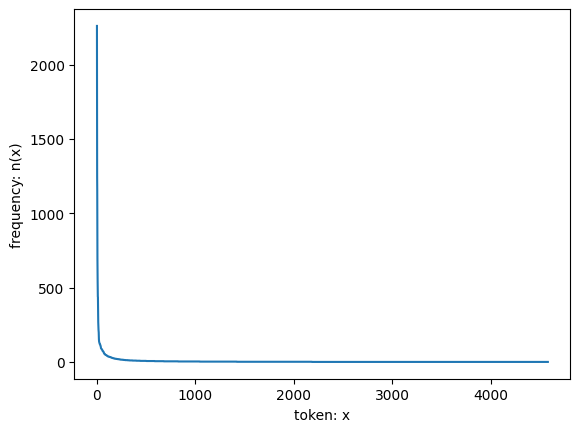

In [36]:
import matplotlib.pyplot as plt
freqs = [freq for token, freq in vocab.token_freqs]
plt.figure()
plt.plot(freqs)
plt.xlabel('token: x')
plt.ylabel('frequency: n(x)')
# plt.xscale('log')
# plt.yscale('log')
plt.show()

After dealing with the first few words as exceptions,
all the remaining words roughly follow a straight line on a log--log plot.
This phenomenon is captured by *Zipf's law*,
which states that the frequency $n_i$
of the $i^\textrm{th}$ most frequent word is:

$$n_i \propto \frac{1}{i^\alpha},$$


which is equivalent to

$$\log n_i = -\alpha \log i + c,$$

where $\alpha$ is the exponent that characterizes
the distribution and $c$ is a constant.
This should already give us pause for thought if we want
to model words by counting statistics.
After all, we will significantly overestimate the frequency of the tail, also known as the infrequent words. But [**what about the other word combinations, such as two consecutive words (bigrams), three consecutive words (trigrams)**], and beyond?
Let's see whether the bigram frequency behaves in the same manner as the single word (unigram) frequency.


In [43]:
# Build bigram tokens from consecutive word pairs:
# (words[0], words[1]), (words[1], words[2]), ..., (words[n-2], words[n-1])
# Then join each pair into a single string like "word_i--word_{i+1}".

words = text.split()
print("words part 1:",words[:-1])
print("words part 2:",words[1:])
bigram_tokens=[]
for  pair in zip(words[:-1], words[1:]):
  bigram_tokens.append("--".join(pair))

print("bigram_tokens:",bigram_tokens)
# bigram_tokens = ['--'.join(pair) for pair in zip(words[:-1], words[1:])]
## TODO

# Create a vocabulary object for these bigram tokens (counts frequencies, assigns indices, etc.)

# bigram_vocab = Vocab(bigram_tokens)
bigram_vocab= Vocab(bigram_tokens)

# Show the top 10 most frequent bigrams (token, frequency) pairs
print("bigram top10 freq",bigram_vocab.token_freqs[:10])

words part 1: ['the', 'time', 'machine', 'by', 'h', 'g', 'wells', 'i', 'the', 'time', 'traveller', 'for', 'so', 'it', 'will', 'be', 'convenient', 'to', 'speak', 'of', 'him', 'was', 'expounding', 'a', 'recondite', 'matter', 'to', 'us', 'his', 'grey', 'eyes', 'shone', 'and', 'twinkled', 'and', 'his', 'usually', 'pale', 'face', 'was', 'flushed', 'and', 'animated', 'the', 'fire', 'burned', 'brightly', 'and', 'the', 'soft', 'radiance', 'of', 'the', 'incandescent', 'lights', 'in', 'the', 'lilies', 'of', 'silver', 'caught', 'the', 'bubbles', 'that', 'flashed', 'and', 'passed', 'in', 'our', 'glasses', 'our', 'chairs', 'being', 'his', 'patents', 'embraced', 'and', 'caressed', 'us', 'rather', 'than', 'submitted', 'to', 'be', 'sat', 'upon', 'and', 'there', 'was', 'that', 'luxurious', 'after', 'dinner', 'atmosphere', 'when', 'thought', 'roams', 'gracefully', 'free', 'of', 'the', 'trammels', 'of', 'precision', 'and', 'he', 'put', 'it', 'to', 'us', 'in', 'this', 'way', 'marking', 'the', 'points', 'w

In [46]:
# Build trigram tokens from consecutive word pairs:
# (words[0], words[1]), (words[1], words[2]), ..., (words[n-2], words[n-1])
# Then join each pair into a single string like "word_i--word_{i+1}".

words = text.split()
print("words part 1:",words[:-2])
print("words part 2:",words[1:-1])
print("words part 3:",words[2:])
trigram_tokens=[]
for  triplet in zip(words[:-2], words[1:-1],words[2:]):
  trigram_tokens.append("--".join(triplet))

print("trigram_tokens:",trigram_tokens)
# bigram_tokens = ['--'.join(pair) for pair in zip(words[:-1], words[1:])]
## TODO

# Create a vocabulary object for these bigram tokens (counts frequencies, assigns indices, etc.)

# bigram_vocab = Vocab(bigram_tokens)
triram_vocab= Vocab(trigram_tokens)

# # Show the top 10 most frequent bigrams (token, frequency) pairs
print("trigram top10 freq",triram_vocab.token_freqs[:10])

words part 1: ['the', 'time', 'machine', 'by', 'h', 'g', 'wells', 'i', 'the', 'time', 'traveller', 'for', 'so', 'it', 'will', 'be', 'convenient', 'to', 'speak', 'of', 'him', 'was', 'expounding', 'a', 'recondite', 'matter', 'to', 'us', 'his', 'grey', 'eyes', 'shone', 'and', 'twinkled', 'and', 'his', 'usually', 'pale', 'face', 'was', 'flushed', 'and', 'animated', 'the', 'fire', 'burned', 'brightly', 'and', 'the', 'soft', 'radiance', 'of', 'the', 'incandescent', 'lights', 'in', 'the', 'lilies', 'of', 'silver', 'caught', 'the', 'bubbles', 'that', 'flashed', 'and', 'passed', 'in', 'our', 'glasses', 'our', 'chairs', 'being', 'his', 'patents', 'embraced', 'and', 'caressed', 'us', 'rather', 'than', 'submitted', 'to', 'be', 'sat', 'upon', 'and', 'there', 'was', 'that', 'luxurious', 'after', 'dinner', 'atmosphere', 'when', 'thought', 'roams', 'gracefully', 'free', 'of', 'the', 'trammels', 'of', 'precision', 'and', 'he', 'put', 'it', 'to', 'us', 'in', 'this', 'way', 'marking', 'the', 'points', 'w

One thing is notable here. Out of the ten most frequent word pairs, nine are composed of both stop words and only one is relevant to the actual book---"the time". Furthermore, let's see whether the trigram frequency behaves in the same manner.


In [13]:
trigram_tokens = ['--'.join(triple) for triple in zip(words[:-2], words[1:-1], words[2:])]
trigram_vocab = Vocab(trigram_tokens)
trigram_vocab.token_freqs[:10]

[('the--time--traveller', 59),
 ('the--time--machine', 30),
 ('the--medical--man', 24),
 ('it--seemed--to', 16),
 ('it--was--a', 15),
 ('here--and--there', 15),
 ('seemed--to--me', 14),
 ('i--did--not', 14),
 ('i--saw--the', 13),
 ('i--began--to', 13)]

Now, let's [**visualize the token frequency**] among these three models: unigrams, bigrams, and trigrams.


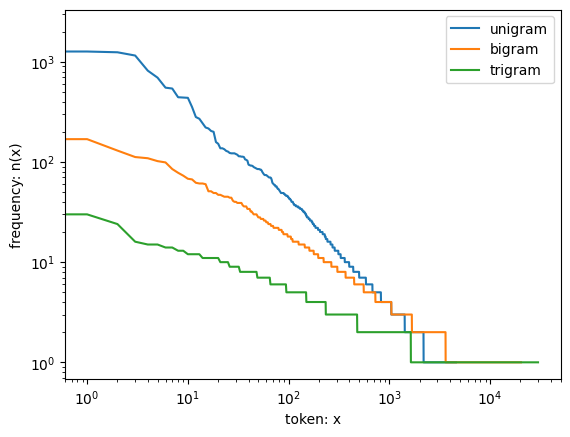

In [49]:
import matplotlib.pyplot as plt

bigram_freqs  = [freq for token, freq in bigram_vocab.token_freqs]
trigram_freqs = [freq for token, freq in trigram_vocab.token_freqs]

plt.figure()
plt.plot(freqs, label='unigram')
plt.plot(bigram_freqs, label='bigram')
plt.plot(trigram_freqs, label='trigram')

plt.xlabel('token: x')
plt.ylabel('frequency: n(x)')
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.show()

This figure is quite exciting.
First, beyond unigram words, sequences of words
also appear to be following Zipf's law,
albeit with a smaller exponent
$\alpha$ in :eqref:`eq_zipf_law`,
depending on the sequence length.
Second, the number of distinct $n$-grams is not that large.
This gives us hope that there is quite a lot of structure in language.
Third, many $n$-grams occur very rarely.
This makes certain methods unsuitable for language modeling
and motivates the use of deep learning models.
We will discuss this in the next section.


## Summary

Text is among the most common forms of sequence data encountered in deep learning.
Common choices for what constitutes a token are characters, words, and word pieces.
To preprocess text, we usually (i) split text into tokens; (ii) build a vocabulary to map token strings to numerical indices; and (iii) convert text data into token indices for models to manipulate.
In practice, the frequency of words tends to follow Zipf's law. This is true not just for individual words (unigrams), but also for $n$-grams.

